In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
BASE_PATH = r"C:\Users\Thomas\Desktop\distributed\experiments\real"
ALGORITHMS = ["Cheap If Possible", "Greedy", "Threshold-Based Scheduler", "Uniform Progression Scheduler", "Intelligent Bidding"]
RUNS = range(48) # 12 workloads for each algorithm

In [3]:
def calculate_runtime_from_service(service_file):
    """
    Calculate the total runtime based on the service file, 
    finding the earliest timestamp where all tasks are completed.
    """

    df = pd.read_parquet(service_file)

    # check columns are present
    if 'timestamp' in df.columns and 'tasks_completed' in df.columns and 'tasks_total' in df.columns:
        # find the row where all tasks are completed
        completion_row = df[df['tasks_completed'] == df['tasks_total']]

        if not completion_row.empty:
            # find the earliest timestamp where all tasks are completed
            completion_time = completion_row['timestamp'].min()
            return completion_time
        else:
            print("Tasks were not fully completed in this file.")
            return None
    else:
        print("Required columns ('timestamp', 'tasks_completed', 'tasks_total') are missing.")
        return None

In [4]:
runtime_results = []

# calculate runtime for each run, per algorithm
for algorithm in ALGORITHMS:
    algorithm_path = os.path.join(BASE_PATH, algorithm)
    algorithm_results = {"Algorithm": algorithm, "Runtimes": []}

    for run in RUNS:
        service_path = os.path.join(algorithm_path, "raw-output", str(run), "seed=0", "service.parquet")
        if os.path.exists(service_path):
            runtime = calculate_runtime_from_service(service_path)
            if runtime is not None:
                algorithm_results["Runtimes"].append(runtime)
            else:
                algorithm_results["Runtimes"].append(0)  # zero if tasks were not completed
        else:
            print(f"File not found: {service_path}")
            algorithm_results["Runtimes"].append(0)  # zero if the file is missing

    runtime_results.append(algorithm_results)


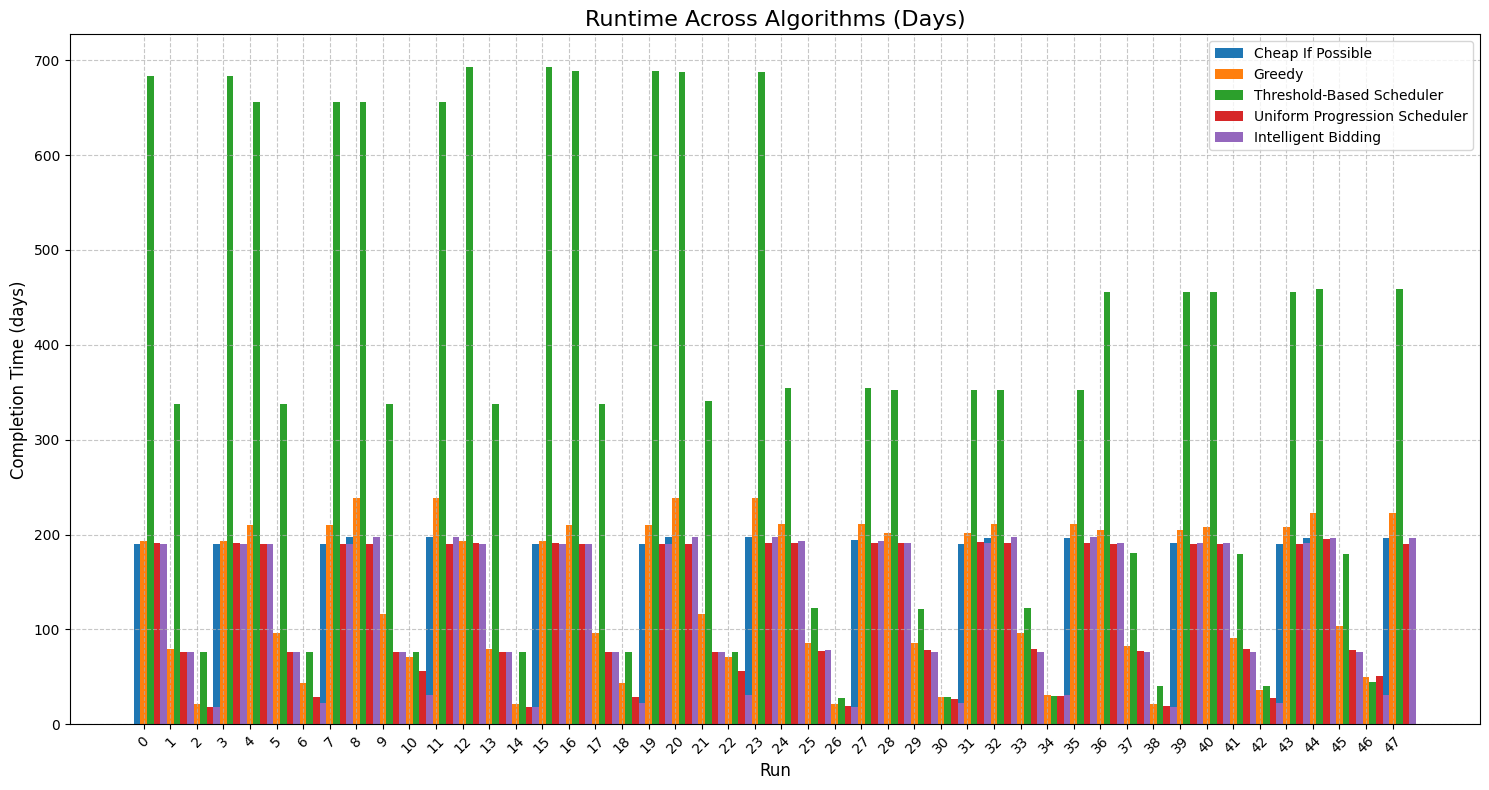

In [5]:
conversion_factor = 86400  # conversion of seconds to days
bar_width = 0.25
x_positions = range(len(RUNS))

plt.figure(figsize=(15, 8))
for i, algorithm_results in enumerate(runtime_results):
    plt.bar(
        [x + i * bar_width for x in x_positions], 
        [t / conversion_factor for t in algorithm_results["Runtimes"]],  # convert to days
        width=bar_width, 
        label=algorithm_results["Algorithm"]
    )

plt.title("Runtime Across Algorithms (Days)", fontsize=16)
plt.xlabel("Run", fontsize=12)
plt.ylabel("Completion Time (days)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(ticks=[x + bar_width for x in x_positions], labels=RUNS, rotation=45)
plt.tight_layout()
plt.show()


hard to read, overlapping graphs


__The following code is for Figure 3:__

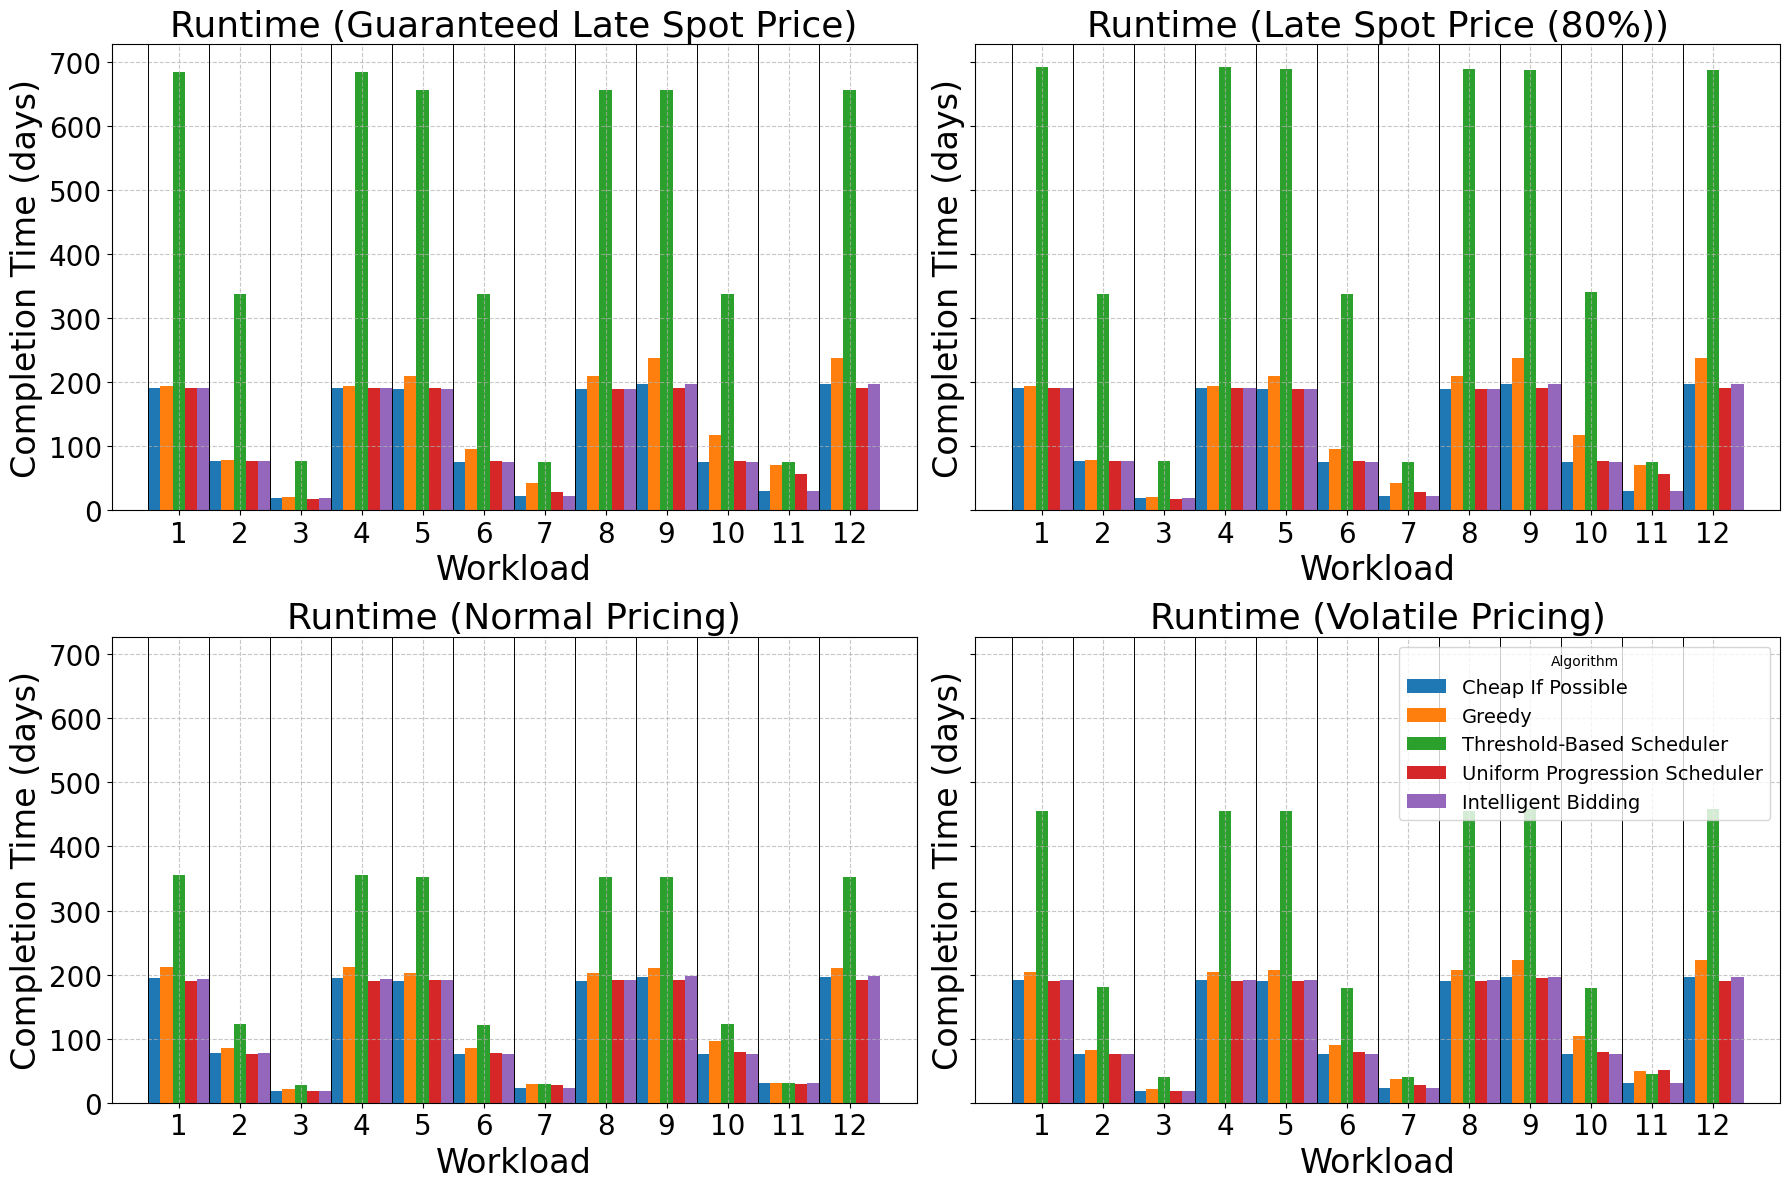

In [ ]:
bar_width = 0.2
x_positions = range(12) # 12 workloads
num_algorithms = len(runtime_results)  # number of algorithms to be plotted


fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
axes = axes.flatten()  # flatten for easier iteration

sections = ["Guaranteed Late Spot Price", "Late Spot Price (80%)", "Normal Pricing", "Volatile Pricing"]

for idx, ax in enumerate(axes):
    start = idx * 12
    end = start + 12

    for i, algorithm_results in enumerate(runtime_results):
        runtimes_subset = algorithm_results["Runtimes"][start:end]  # subset of runtimes
        ax.bar(
            [x + i * bar_width for x in x_positions], 
            [t / conversion_factor for t in runtimes_subset],  # convert to days
            width=bar_width, 
            label=algorithm_results["Algorithm"] if idx == 3 else None  # label once (final plot)
        )

    # vertical lines halfway between each group
    for x in x_positions:
        ax.axvline(x - bar_width / 2, color='black', linestyle='-', linewidth=0.7)

    ax.set_title(f"Runtime ({sections[idx]})", fontsize=30)
    ax.set_xlabel("Workload", fontsize=28)
    ax.set_ylabel("Completion Time (days)", fontsize=28)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.tick_params(axis='y', labelsize=24)
    ax.set_xticks([x + (num_algorithms - 1) * bar_width / 2 for x in x_positions])
    ax.set_xticklabels(range(1, 13), fontsize=24)

# legend to the second subplot in the upper right
axes[3].legend(title="Algorithm", loc="upper right", fontsize=14)

plt.tight_layout()
plt.show()


below is code to exclude the threshold based scheduler, which ultimately wasn't used.

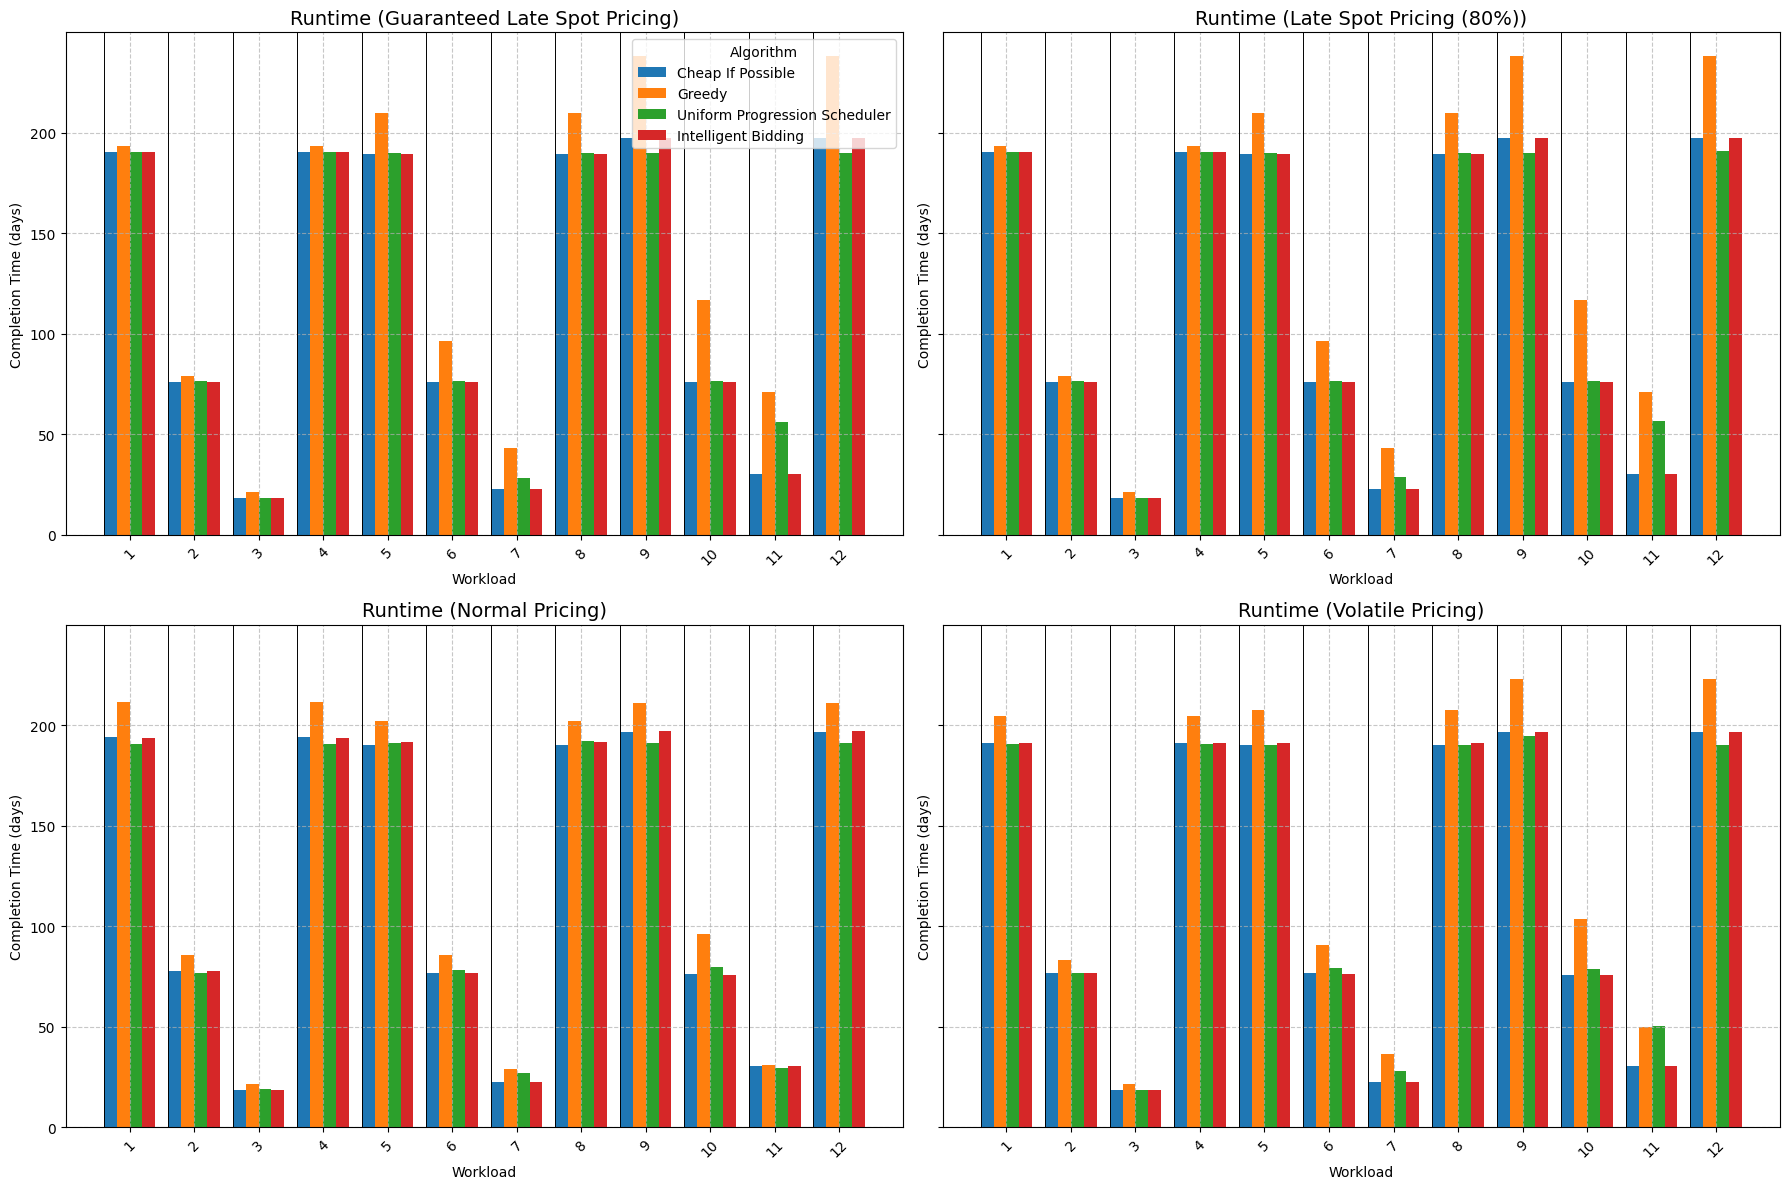

In [ ]:
conversion_factor = 86400
bar_width = 0.2 
x_positions = range(12)


# Filter runtime_results to exclude Threshold-Based Scheduler
filtered_runtime_results = [
    algorithm_results for algorithm_results in runtime_results
    if algorithm_results["Algorithm"] != "Threshold-Based Scheduler"
]

num_algorithms = len(filtered_runtime_results) 


fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
axes = axes.flatten()

sections = ["Guaranteed Late Spot Price", "Late Spot Price (80%)", "Normal Pricing", "Volatile Pricing"]

# Loop through each category and plot
for idx, ax in enumerate(axes):
    start = idx * 12
    end = start + 12

    for i, algorithm_results in enumerate(filtered_runtime_results):
        runtimes_subset = algorithm_results["Runtimes"][start:end]
        ax.bar(
            [x + i * bar_width for x in x_positions], 
            [t / conversion_factor for t in runtimes_subset],
            width=bar_width, 
            label=algorithm_results["Algorithm"] if idx == 0 else None
        )


    for x in x_positions:
        ax.axvline(x - bar_width / 2, color='black', linestyle='-', linewidth=0.7)

    ax.set_title(f"Runtime ({sections[idx]})", fontsize=14)
    ax.set_xlabel("Workload", fontsize=10)
    ax.set_ylabel("Completion Time (days)", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xticks([x + (num_algorithms - 1) * bar_width / 2 for x in x_positions])
    ax.set_xticklabels(range(1, 13), rotation=45)


axes[0].legend(title="Algorithm", loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()
